# BuildFlowMatch (waft-a2, dav2) - demo fine-tuning in Colab

Pasi: clone repo -> instalare dependinte -> checkpoint + encoder dav2 (din Google Drive) -> incarcare set propriu de date (poze + ground truth) -> fine-tuning cateva pasi -> vizualizare flux optic inainte/dupa.

## 1. Clonare repo
Inlocuieste `REPO_URL` cu URL-ul repo-ului tau (cel pe care l-ai facut push cu acest folder minimal).

In [9]:
REPO_URL = "https://github.com/rosemariestoica13/BuildFlowMatch.git"

!git clone $REPO_URL buildflowmatch
%cd buildflowmatch

Cloning into 'buildflowmatch'...
remote: Enumerating objects: 87, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 87 (delta 24), reused 79 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (87/87), 151.11 KiB | 1.23 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/buildflowmatch/buildflowmatch/buildflowmatch


## 2. Instalare dependinte

In [10]:
!pip install -q -r requirements.txt

## 3. Checkpoint-uri (BuildFlowMatch + encoder dav2) din Google Drive
Se descarca automat din folderul tau Google Drive:
https://drive.google.com/drive/folders/1jg476sKB1r9xMA2ecoMvWVLHDtpl5HMi

Ca sa mearga descarcarea automata (fara login), folderul trebuie setat pe
**"Oricine are linkul" -> Vizualizator** (Anyone with the link - Viewer). Daca nu merge,
foloseste celula de fallback cu upload manual de mai jos.

In [11]:
!pip install -q gdown

import os, shutil, gdown

FOLDER_URL = "https://drive.google.com/drive/folders/1jg476sKB1r9xMA2ecoMvWVLHDtpl5HMi"

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('depth-anything-ckpts', exist_ok=True)

gdown.download_folder(url=FOLDER_URL, output='drive_ckpts', quiet=False, use_cookies=False)

for fname in os.listdir('drive_ckpts'):
    src = os.path.join('drive_ckpts', fname)
    if 'depth_anything' in fname.lower():
        shutil.move(src, os.path.join('depth-anything-ckpts', fname))
    else:
        shutil.move(src, os.path.join('checkpoints', 'sintel-gm-final.pth'))

print('checkpoints/:', os.listdir('checkpoints'))
print('depth-anything-ckpts/:', os.listdir('depth-anything-ckpts'))

Retrieving folder contents


Processing file 1WqBFsyrFZmQKDh1Tcd8en_a9f_QzJdLn depth_anything_v2_vits.pth
Processing file 12MUTZLBScez7uLwRsMuxveYVyM3mz2pp final.pth


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1WqBFsyrFZmQKDh1Tcd8en_a9f_QzJdLn
From (redirected): https://drive.google.com/uc?id=1WqBFsyrFZmQKDh1Tcd8en_a9f_QzJdLn&confirm=t&uuid=995b5fb2-7f28-4117-94ee-ca8e23864e0c
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/drive_ckpts/depth_anything_v2_vits.pth
100%|██████████| 99.2M/99.2M [00:02<00:00, 39.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12MUTZLBScez7uLwRsMuxveYVyM3mz2pp
From (redirected): https://drive.google.com/uc?id=12MUTZLBScez7uLwRsMuxveYVyM3mz2pp&confirm=t&uuid=774ec640-75ec-4147-92db-f27baf5abc5e
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/drive_ckpts/final.pth
100%|██████████| 229M/229M [00:03<00:00, 60.5MB/s]

checkpoints/: ['.gitkeep', 'sintel-gm-final.pth']
depth-anything-ckpts/: ['.gitkeep', 'depth_anything_v2_vits.pth']



Download completed


## 5. Setul tau de date (poze + ground truth) din Google Drive
Se descarca automat din folderul tau Google Drive:
https://drive.google.com/drive/folders/1w0Y16win5utMvTPW0ryLbQSUv93ojEon

Folderul e plat (fara subfoldere) si contine cate 3 fisiere per pereche, numite dupa
convenția KITTI: `xxxxxx_10.png` (image1), `xxxxxx_11.png` (image2) si `xxxxxx_10_gt.png`
(ground truth, format KITTI 16-bit — vezi `dataloader/custom.py`). Trebuie sa fie setat
pe **"Oricine are linkul" -> Vizualizator**, altfel foloseste fallback-ul cu upload de
arhiva `.zip` de mai jos.

In [13]:
!pip install -q gdown

import os, shutil, gdown

DATA_FOLDER_URL = "https://drive.google.com/drive/folders/1w0Y16win5utMvTPW0ryLbQSUv93ojEon"

for sub in ('image1', 'image2', 'flow'):
    os.makedirs(f'data/custom/{sub}', exist_ok=True)

gdown.download_folder(url=DATA_FOLDER_URL, output='drive_data', quiet=False, use_cookies=False)

for fname in sorted(os.listdir('drive_data')):
    src = os.path.join('drive_data', fname)
    stem = os.path.splitext(fname)[0]
    if stem.endswith('_gt'):
        dst = os.path.join('data/custom/flow', fname)
    elif stem.endswith('_11'):
        dst = os.path.join('data/custom/image2', fname)
    elif stem.endswith('_10'):
        dst = os.path.join('data/custom/image1', fname)
    else:
        raise ValueError(f"Nu stiu unde sa pun {fname} (astept sufix _10, _11 sau _gt)")
    shutil.move(src, dst)

print('image1:', os.listdir('data/custom/image1'))
print('image2:', os.listdir('data/custom/image2'))
print('flow:  ', os.listdir('data/custom/flow'))

Retrieving folder contents


Processing file 1eC8YeIhczIxmVPu4hshousKrl0niHPnb 000007_10_gt.png
Processing file 1_QnuLAlwk_Uu0573c2CWeKtkUeusHYF9 000007_10.png
Processing file 1f--UF2UkMSjBsB0ataBsaeudHXMOXQFn 000007_11.png


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eC8YeIhczIxmVPu4hshousKrl0niHPnb
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/drive_data/000007_10_gt.png
100%|██████████| 619k/619k [00:00<00:00, 7.38MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_QnuLAlwk_Uu0573c2CWeKtkUeusHYF9
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/drive_data/000007_10.png
100%|██████████| 876k/876k [00:00<00:00, 8.12MB/s]
Downloading...
From: https://drive.google.com/uc?id=1f--UF2UkMSjBsB0ataBsaeudHXMOXQFn
To: /content/buildflowmatch/buildflowmatch/buildflowmatch/drive_data/000007_11.png
100%|██████████| 868k/868k [00:00<00:00, 7.40MB/s]

image1: ['000007_10.png']
image2: ['000007_11.png']
flow:   ['000007_10_gt.png']



Download completed


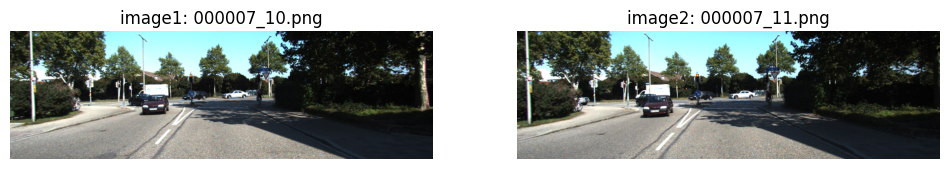

In [14]:
import matplotlib.pyplot as plt
import cv2
from glob import glob

img1_path = sorted(glob('data/custom/image1/*'))[0]
img2_path = sorted(glob('data/custom/image2/*'))[0]

img1 = cv2.cvtColor(cv2.imread(img1_path), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(img2_path), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1); ax[0].set_title(f'image1: {os.path.basename(img1_path)}'); ax[0].axis('off')
ax[1].imshow(img2); ax[1].set_title(f'image2: {os.path.basename(img2_path)}'); ax[1].axis('off')
plt.show()

## 6. Fine-tuning
Ruleaza cativa pasi de antrenare pornind de la checkpoint, pe setul tau de date.

In [15]:
!python finetune_demo.py \
    --cfg config/a2/dav2/sintel-gm.json \
    --ckpt checkpoints/sintel-gm-final.pth \
    --data_dir data/custom \
    --steps 100 \
    --out_ckpt checkpoints/finetuned.pth

xFormers not available
xFormers not available
64
model.safetensors: 100% 88.2M/88.2M [00:01<00:00, 49.6MB/s]
Loaded checkpoint from checkpoints/sintel-gm-final.pth
Custom dataset: 1 image pair(s) found in data/custom
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
[demo_out/flow_before.jpg] EPE vs ground truth: 0.408
step 0000 | loss 6.4444 | epe 1.818
step 0001 | loss 7.2228 | epe 1.789
step 0002 | loss 6.4353 | epe 1.488
step 0003 | loss 5.6512 | epe 1.168
step 0004 | loss 5.0697 | epe 1.014
step 0005 | loss 4.8683 | epe 0.956
step 0006 | loss 5.0304 | epe 0.985
step 0007 | loss 4.9629 | epe 0.966
step 0008 | loss 5.0452 | epe 1.065
step 0009 | loss 4.8428 | epe 0.953
step 0010 | loss 4.6492 | epe 0.853
step 0011 | los

## 7. Vizualizare inainte / dupa fine-tuning

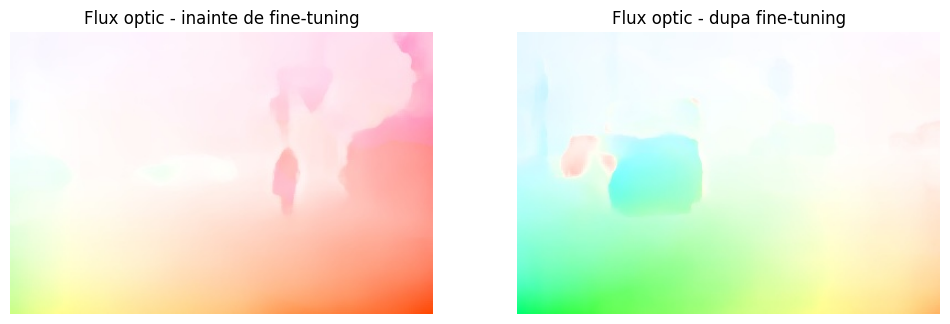

In [16]:
import matplotlib.pyplot as plt
import cv2

before = cv2.cvtColor(cv2.imread('demo_out/flow_before.jpg'), cv2.COLOR_BGR2RGB)
after = cv2.cvtColor(cv2.imread('demo_out/flow_after.jpg'), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(before); ax[0].set_title('Flux optic - inainte de fine-tuning'); ax[0].axis('off')
ax[1].imshow(after); ax[1].set_title('Flux optic - dupa fine-tuning'); ax[1].axis('off')
plt.show()

## 8. Inferenta pe imagini noi (fara ground truth) din Google Drive
Se descarca o pereche de imagini din alt folder Google Drive (fara flux optic de referinta):
https://drive.google.com/drive/folders/1UGqKcwzKAb35TGcCYyLwKqEqzvMXjwZi

Ruleaza inferenta cu checkpoint-ul fine-tuned (`checkpoints/finetuned.pth`).

In [ ]:
!pip install -q gdown

import os, gdown

INFER_FOLDER_URL = "https://drive.google.com/drive/folders/1UGqKcwzKAb35TGcCYyLwKqEqzvMXjwZi"

os.makedirs('infer_data', exist_ok=True)
gdown.download_folder(url=INFER_FOLDER_URL, output='infer_data', quiet=False, use_cookies=False)

print(sorted(os.listdir('infer_data')))

In [ ]:
imgs = sorted(os.listdir('infer_data'))

!python infer_demo.py \
    --cfg config/a2/dav2/sintel-gm.json \
    --ckpt checkpoints/finetuned.pth \
    --img1 infer_data/{imgs[0]} \
    --img2 infer_data/{imgs[1]} \
    --out demo_out/infer_flow.jpg

In [ ]:
import matplotlib.pyplot as plt
import cv2

img1 = cv2.cvtColor(cv2.imread(f'infer_data/{imgs[0]}'), cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(cv2.imread(f'infer_data/{imgs[1]}'), cv2.COLOR_BGR2RGB)
flow_vis = cv2.cvtColor(cv2.imread('demo_out/infer_flow.jpg'), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img1); ax[0].set_title('image1'); ax[0].axis('off')
ax[1].imshow(img2); ax[1].set_title('image2'); ax[1].axis('off')
ax[2].imshow(flow_vis); ax[2].set_title('flux optic (inferenta)'); ax[2].axis('off')
plt.show()